!pip install tensorflow opencv-python matplotlib

In [165]:
! pip list

Package                           Version
--------------------------------- --------------------
absl-py                           2.4.0
aiobotocore                       2.25.0
aiodns                            3.5.0
aiohappyeyeballs                  2.6.1
aiohttp                           3.13.2
aioitertools                      0.12.0
aiosignal                         1.4.0
alabaster                         0.7.16
altair                            5.5.0
anaconda-anon-usage               0.7.5
anaconda-auth                     0.12.0
anaconda-catalogs                 0.2.0
anaconda-cli-base                 0.7.0
anaconda-client                   1.14.0
anaconda-navigator                2.7.0
anaconda-project                  0.11.1
annotated-types                   0.6.0
anyio                             4.10.0
appdirs                           1.4.4
archspec                          0.2.5
argon2-cffi                       21.3.0
argon2-cffi-bindings              25.1.0
arrow        

In [166]:
import tensorflow as tf
import os

In [167]:
os.path.join('data','happy')

'data\\happy'

In [168]:
gpus = tf.config.experimental.list_physical_devices('GPU')

In [169]:
gpus

[]

In [170]:
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu,True)

In [171]:
import tensorflow as tf 
print(tf.__version__)

2.21.0


In [172]:
import cv2

In [173]:
!pip install pillow

Defaulting to user installation because normal site-packages is not writeable


In [174]:
img = cv2.imread(os.path.join('data','happy','154006829.jpg'))

In [175]:
type(img)

numpy.ndarray

In [176]:
img.shape

(3744, 5616, 3)

In [177]:
import matplotlib.pyplot as plt

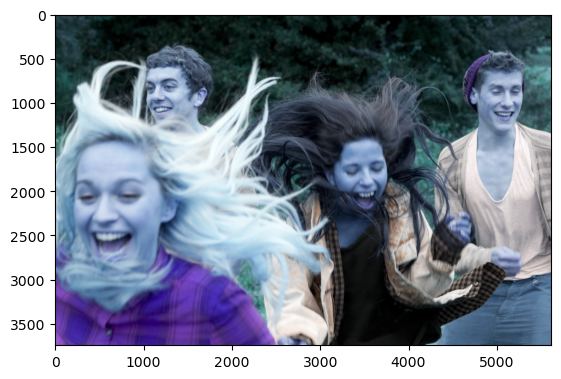

In [178]:
plt.imshow(img)

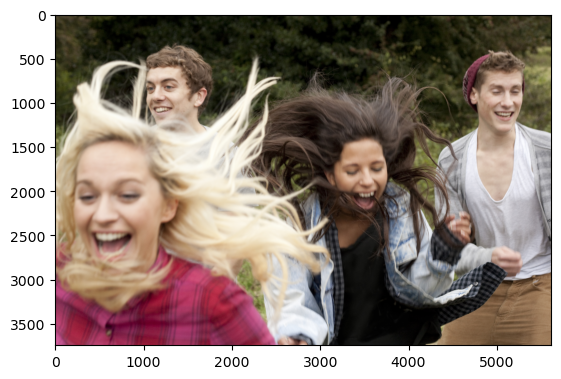

In [179]:
plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.show()

In [180]:
data_dir ='data'

In [181]:
for image_class in os.listdir(data_dir):
    for image in os.listdir(os.path.join(data_dir,image_class)):
        image_path = os.path.join(data_dir, image_class , image)
        try:
            img = cv2.imread(image_path)
            tip= imghdr.what(image_path)
            if ti not in image_exts:
                print('Image not in ext list {}'.format(image_path))
                os.remove(image_path)
        except Exception as e:
            print('Issue with image {}'.format(image_path))

Issue with image data\happy\05-12-21-happy-people.jpg
Issue with image data\happy\07-120104-happy_people_are_not_nice_people.jpg
Issue with image data\happy\1-2.jpg
Issue with image data\happy\1000_F_42220133_toAU6USGY9jVr2XJFLssfG00cSYIJ173.jpg
Issue with image data\happy\11-Habits-of-Truly-Happy-People.jpg
Issue with image data\happy\154006829.jpg
Issue with image data\happy\170404-happy-workers-feature.jpg
Issue with image data\happy\1902539.jpg
Issue with image data\happy\1902540.jpg
Issue with image data\happy\1902587.jpg
Issue with image data\happy\1920px-face-smile.svg_.png.jpg
Issue with image data\happy\1HEoLBLidT2u4mhJ0oiDgig.png
Issue with image data\happy\227-2271622_happy-people-business-team-celebrating-png.png
Issue with image data\happy\60632274._UY200_.jpg
Issue with image data\happy\7-Habits-of-Happy-People-image.jpeg
Issue with image data\happy\7-principles-of-successful-and-happy-people.png
Issue with image data\happy\7Y57w0983emdERAoQylUHIGkoEk1cIFvPkXDbeA2lVA.jpg


In [182]:
import numpy as np

In [183]:
from matplotlib import pyplot as plt 

In [184]:
data = tf.keras.utils.image_dataset_from_directory('data')

Found 305 files belonging to 2 classes.


In [185]:
tf.keras.utils.image_dataset_from_directory('data')

Found 305 files belonging to 2 classes.


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [186]:
data_iterator = data.as_numpy_iterator()

In [187]:
data_iterator

NumpyIterator(iterator=<tensorflow.python.data.ops.iterator_ops.OwnedIterator object at 0x00000297C4951650>)

In [188]:
batch = data_iterator.next()

In [189]:
batch

(array([[[[129.03711  , 145.03711  , 134.03711  ],
          [130.33398  , 146.33398  , 135.33398  ],
          [133.92773  , 149.92773  , 138.92773  ],
          ...,
          [248.25781  , 245.18555  , 245.07227  ],
          [249.       , 245.       , 246.       ],
          [249.       , 245.       , 246.       ]],
 
         [[129.03711  , 145.03711  , 134.03711  ],
          [130.39769  , 146.39769  , 135.39769  ],
          [134.39381  , 150.39381  , 139.39381  ],
          ...,
          [247.79173  , 244.5071   , 244.5      ],
          [248.42773  , 244.42773  , 245.42773  ],
          [248.42773  , 244.42773  , 245.42773  ]],
 
         [[129.04776  , 145.04776  , 134.04776  ],
          [130.70045  , 146.70045  , 135.70045  ],
          [134.74219  , 150.74219  , 139.74219  ],
          ...,
          [247.20952  , 243.76616  , 243.83842  ],
          [247.71289  , 243.71289  , 244.71289  ],
          [247.71289  , 243.71289  , 244.71289  ]],
 
         ...,
 
         [[2

In [190]:
len(batch)

2

In [191]:
batch[0].shape

(32, 256, 256, 3)

In [192]:
batch[1]

array([1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 0, 1, 0], dtype=int32)

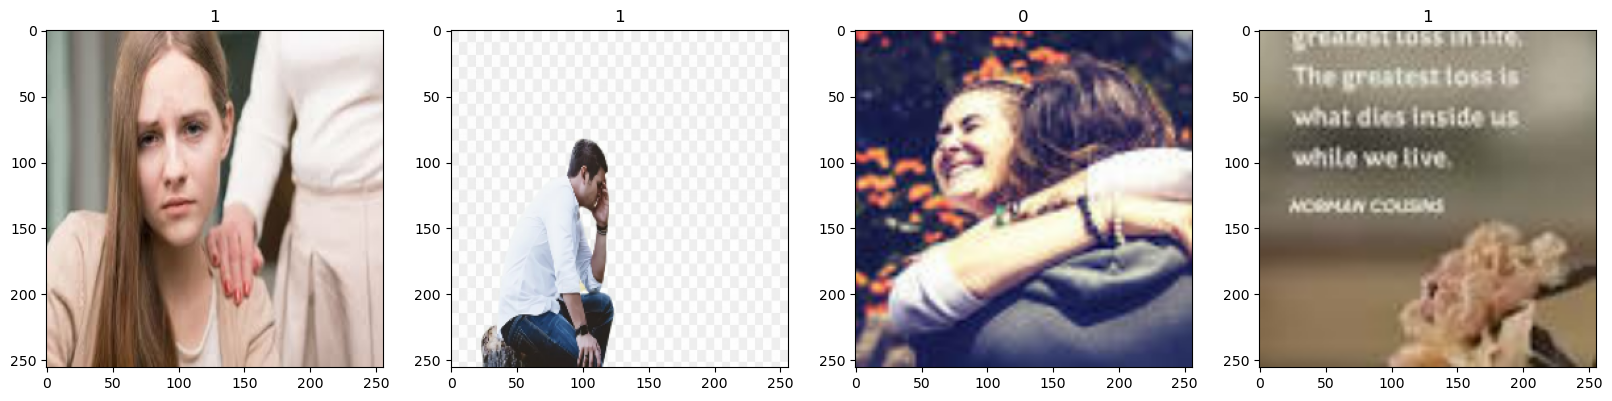

In [193]:
fig, ax = plt.subplots(ncols=4,figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

In [194]:
scaled = batch[0]/255

In [195]:
scaled.max()

np.float32(1.0)

In [196]:
# Preprocess Data

In [197]:
data = data.map(lambda x,y: (x/255 , y))

In [198]:
data.as_numpy_iterator().next()

(array([[[[0.02745098, 0.01960784, 0.02352941],
          [0.02745098, 0.01960784, 0.02352941],
          [0.02745098, 0.01960784, 0.02352941],
          ...,
          [0.02352941, 0.02352941, 0.02352941],
          [0.02352941, 0.02352941, 0.02352941],
          [0.02352941, 0.02352941, 0.02352941]],
 
         [[0.02745098, 0.01960784, 0.02352941],
          [0.02745098, 0.01960784, 0.02352941],
          [0.02745098, 0.01960784, 0.02352941],
          ...,
          [0.02352941, 0.02352941, 0.02352941],
          [0.02352941, 0.02352941, 0.02352941],
          [0.02352941, 0.02352941, 0.02352941]],
 
         [[0.02745098, 0.01960784, 0.02352941],
          [0.02745098, 0.01960784, 0.02352941],
          [0.02745098, 0.01960784, 0.02352941],
          ...,
          [0.02352941, 0.02352941, 0.02352941],
          [0.01960784, 0.01960784, 0.01960784],
          [0.01960784, 0.01960784, 0.01960784]],
 
         ...,
 
         [[0.02352941, 0.01568628, 0.01960784],
          [0.02536

In [199]:
data.as_numpy_iterator().next()[0].max()

np.float32(1.0)

In [200]:
data.as_numpy_iterator().next()[0].min()

np.float32(0.0)

In [201]:
len(data)

10

In [202]:
train_size = int(len(data) * .7)
val_size = int(len(data)* .2)
test_size = int(len(data)*.1)

In [203]:
train_size=val_size=test_size

In [204]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

In [205]:
from tensorflow.keras.models import Sequential


In [206]:
from tensorflow.keras.layers import Conv2D , MaxPooling2D, Dense, Flatten, Dropout

In [207]:
model = Sequential()

In [208]:
model.add(Conv2D(16, (3,3), 1, activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D())

In [209]:
model.add(Conv2D(32,(3,3),1,activation='relu'))
model.add(MaxPooling2D())

In [210]:
model.add(Conv2D(16,(3,3),1,activation='relu'))
model.add(MaxPooling2D())

In [211]:
model.add(Flatten())
model.add(Dense(256,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [212]:
model.compile('adam',loss=tf.losses.BinaryCrossentropy(), metrics=['accuracy'])

In [213]:
!pip install tensorboard

Defaulting to user installation because normal site-packages is not writeable


In [214]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 254, 254, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 127, 127, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 125, 125, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 62, 62, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 60, 60, 16)          │           4,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 30, 30, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 14400)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │       3,686,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,696,625 (14.10 MB)

 Trainable params: 3,696,625 (14.10 MB)

 Non-trainable params: 0 (0.00 B)

In [215]:
logdir = 'logs'

In [216]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

In [217]:
hist = model.fit(train, epochs = 20, validation_data=val,callbacks=[tensorboard_callback])

Epoch 1/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3125 - loss: 0.7047 - val_accuracy: 0.4688 - val_loss: 3.3163
Epoch 2/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 668ms/step - accuracy: 0.5938 - loss: 2.4263 - val_accuracy: 0.5938 - val_loss: 0.7945
Epoch 3/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 702ms/step - accuracy: 0.4062 - loss: 1.0615 - val_accuracy: 0.6562 - val_loss: 0.7179
Epoch 4/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 867ms/step - accuracy: 0.5938 - loss: 0.7517 - val_accuracy: 0.5625 - val_loss: 0.8038
Epoch 5/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 690ms/step - accuracy: 0.5000 - loss: 0.8215 - val_accuracy: 0.5625 - val_loss: 0.7138
Epoch 6/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 768ms/step - accuracy: 0.5000 - loss: 0.7437 - val_accuracy: 0.6562 - val_loss: 0.6519
Epoch 7/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 671ms/step - accuracy: 0.6875 - loss: 0.6531 - val_accuracy: 0.5938 - val_loss: 0.6197
Epoch 8/20
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 718ms/step - accuracy: 0.5312 - loss: 0.6355 - val_accuracy: 0.3125 - val_loss: 0.

In [218]:
hist

In [219]:
hist.history

{'accuracy': [0.3125,
  0.59375,
  0.40625,
  0.59375,
  0.5,
  0.5,
  0.6875,
  0.53125,
  0.375,
  0.6875,
  0.65625,
  0.5625,
  0.625,
  0.59375,
  0.46875,
  0.59375,
  0.65625,
  0.53125,
  0.40625,
  0.46875],
 'loss': [0.704717755317688,
  2.426344633102417,
  1.061471700668335,
  0.7516781687736511,
  0.8214542269706726,
  0.7436580657958984,
  0.6530659198760986,
  0.6354520916938782,
  0.755901575088501,
  0.6021183729171753,
  0.6446739435195923,
  0.6415814161300659,
  0.65183424949646,
  0.6288180947303772,
  0.6547703742980957,
  0.6022998690605164,
  0.55482017993927,
  0.647363543510437,
  0.7305864095687866,
  0.633869469165802],
 'val_accuracy': [0.46875,
  0.59375,
  0.65625,
  0.5625,
  0.5625,
  0.65625,
  0.59375,
  0.3125,
  0.5625,
  0.59375,
  0.6875,
  0.71875,
  0.46875,
  0.5,
  0.78125,
  0.4375,
  0.53125,
  0.5625,
  0.5,
  0.71875],
 'val_loss': [3.316254138946533,
  0.794480562210083,
  0.7178679704666138,
  0.8037962913513184,
  0.7137998938560486,
  

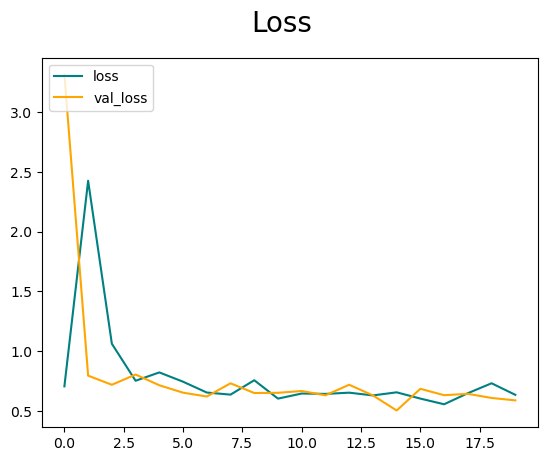

In [220]:
fig = plt.figure()
plt.plot(hist.history['loss'], color ='teal', label ='loss')
plt.plot(hist.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss',fontsize=20)
plt.legend(loc="upper left")
plt.show()

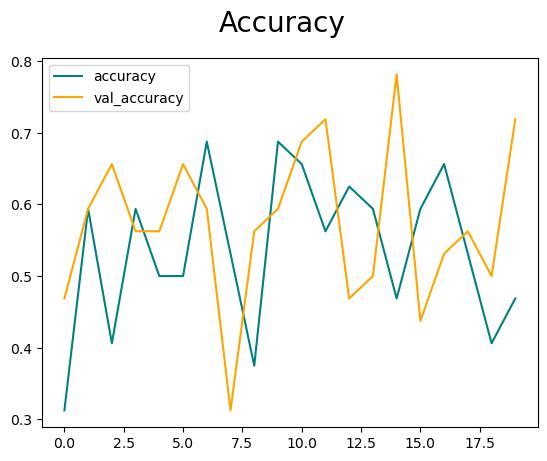

In [221]:
fig = plt.figure()
plt.plot(hist.history['accuracy'], color ='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'],color ='orange',label='val_accuracy')
fig.suptitle('Accuracy',fontsize = 20)
plt.legend(loc="upper left")
plt.show()

In [222]:
from tensorflow.keras.metrics import Precision , Recall , BinaryAccuracy

In [223]:
pre = Precision()
re = Recall()
acc = BinaryAccuracy()

In [224]:
for batch in test.as_numpy_iterator():
    X, y = batch
    yhat = model.predict(X)
    pre.update_state(y,yhat)
    re.update_state(y,yhat)
    acc.update_state(y,yhat)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


In [225]:
print(f'Precision:{pre.result().numpy()}, Recall: {re.result().numpy()} , Accuracy: {acc.result().numpy()}')

Precision:0.800000011920929, Recall: 0.23529411852359772 , Accuracy: 0.5625


In [226]:
import cv2

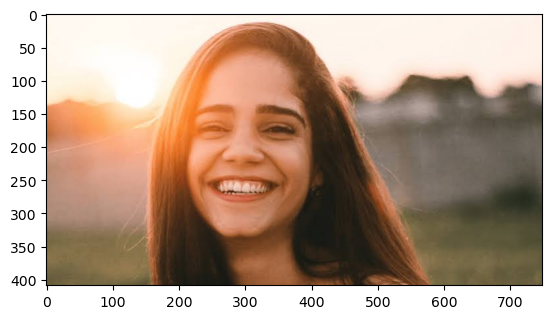

In [227]:
img = cv2.imread('images (1).jpg')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

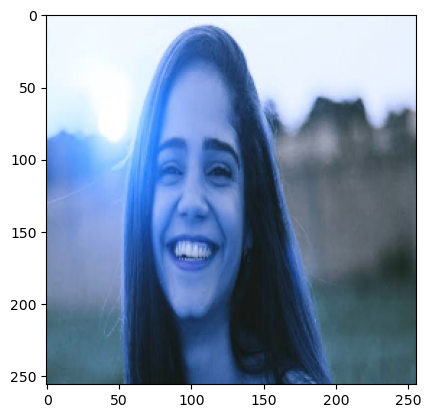

In [228]:
resize = tf.image.resize(img, (256, 256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [232]:
resize.shape

TensorShape([256, 256, 3])

In [233]:
np.expand_dims(resize, 0).shape

(1, 256, 256, 3)

In [235]:
yhat = model.predict(np.expand_dims(resize/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [236]:
yhat

array([[0.5191767]], dtype=float32)

In [259]:
if yhat > 0.6:
    print(f'Predicted class is Sad')
else:
    print(f'Predicted class is Happy')

Predicted class is Happy


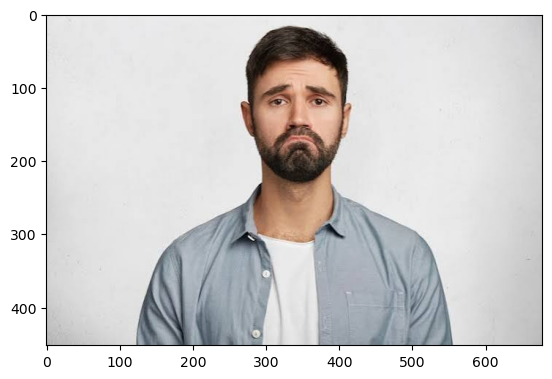

In [239]:
img = cv2.imread('images.jpg')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

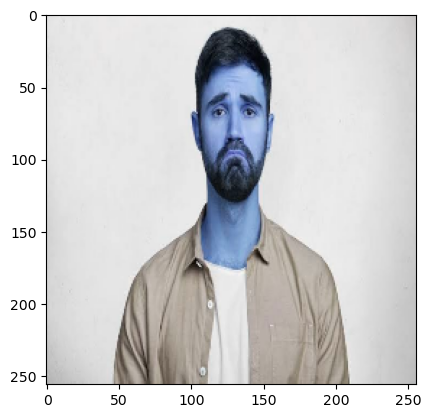

In [240]:
resize = tf.image.resize(img, (256, 256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [241]:
yhat = model.predict(np.expand_dims(resize/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


In [242]:
yhat

array([[0.5070318]], dtype=float32)

In [258]:
if yhat > 0.5:
    print(f'Predicted class is Sad')
else:
    print(f'Predicted class is Happy')

Predicted class is Sad


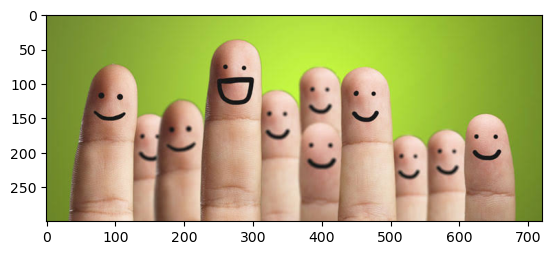

In [251]:
img = cv2.imread('images (2).jpg')
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

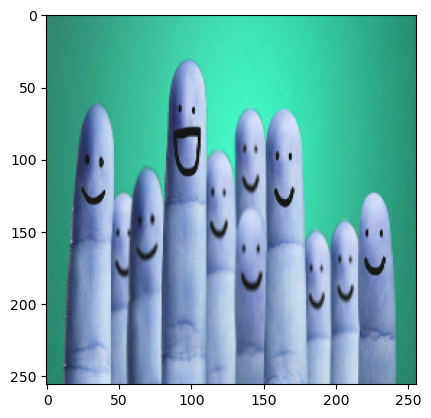

In [252]:
resize = tf.image.resize(img, (256, 256))
plt.imshow(resize.numpy().astype(int))
plt.show()

In [253]:
yhat = model.predict(np.expand_dims(resize/255, 0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


In [254]:
yhat

array([[0.5004872]], dtype=float32)

In [256]:
if yhat > 0.6:
    print(f'Predicted class is Sad')
else:
    print(f'Predicted class is Happy')

Predicted class is Happy
